In [11]:
import pandas as pd

df = pd.read_parquet("/app/datamart/gold/training_dataset/merged_tb.parquet")

df.to_csv("/app/datamart/gold/training_dataset/merged_tb.csv", index=False)

print("Saved CSV")

Saved CSV


In [12]:
df

,Customer_ID,snapshot_date,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,label
0,cus_0x1037,2023-01-01,45.0,15989.085,1086.424,5.0,4.0,2.0,4.0,"[credit-builder loan, auto loan, mortgage loan]",...,105.0,-16.0,-81.0,-126.0,114.0,35.0,85.0,-73.0,76.0,0
1,cus_0x1069,2023-01-01,32.0,58637.340,4799.445,4.0,6.0,10.0,3.0,"[personal loan, auto loan]",...,190.0,-14.0,-96.0,200.0,35.0,130.0,94.0,111.0,75.0,0
2,cus_0x114a,2023-01-01,43.0,15305.460,1230.455,0.0,7.0,2.0,2.0,"[student loan, home equity loan]",...,203.0,26.0,86.0,171.0,125.0,-130.0,257.0,17.0,262.0,0
3,cus_0x1184,2023-01-01,49.0,19867.475,1396.623,3.0,5.0,11.0,3.0,"[student loan, mortgage loan, payday loan]",...,197.0,172.0,96.0,174.0,163.0,37.0,207.0,180.0,118.0,0
4,cus_0x1297,2023-01-01,46.0,57738.060,4881.505,9.0,8.0,30.0,9.0,"[payday loan, personal loan, mortgage loan, ho...",...,12.0,76.0,43.0,183.0,159.0,-26.0,104.0,118.0,184.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11968,cus_0xe6c,2024-12-01,26.0,125597.520,9367.500,1.0,3.0,12.0,4.0,"[debt consolidation loan, student loan]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
11969,cus_0xe99,2024-12-01,48.0,45461.540,3917.462,6.0,3.0,5.0,2.0,"[credit-builder loan, payday loan]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
11970,cus_0xf55,2024-12-01,39.0,78443.480,6358.957,7.0,5.0,23.0,4.0,"[personal loan, home equity loan, mortgage loa...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
11971,cus_0xfd1,2024-12-01,32.0,78666.570,6485.548,3.0,4.0,17.0,4.0,"[personal loan, home equity loan, debt consoli...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [15]:

    drop_cols = [
        "Customer_ID",
        "snapshot_date",
        # "loan_id",
        "Type_of_Loan",
        "label"
    ]

X = df.drop(columns=drop_cols)

X = X.select_dtypes(include=["number"])
X = X.fillna(X.median())

In [16]:
X

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
0,45.0,15989.085,1086.424,5.0,4.0,2.0,4.0,13,15.0,0.50,...,164.0,105.0,-16.0,-81.0,-126.0,114.0,35.0,85.0,-73.0,76.0
1,32.0,58637.340,4799.445,4.0,6.0,10.0,3.0,9,17.0,12.56,...,203.0,190.0,-14.0,-96.0,200.0,35.0,130.0,94.0,111.0,75.0
2,43.0,15305.460,1230.455,0.0,7.0,2.0,2.0,14,2.0,15.95,...,14.0,203.0,26.0,86.0,171.0,125.0,-130.0,257.0,17.0,262.0
3,49.0,19867.475,1396.623,3.0,5.0,11.0,3.0,10,9.0,6.74,...,6.0,197.0,172.0,96.0,174.0,163.0,37.0,207.0,180.0,118.0
4,46.0,57738.060,4881.505,9.0,8.0,30.0,9.0,61,24.0,14.27,...,34.0,12.0,76.0,43.0,183.0,159.0,-26.0,104.0,118.0,184.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11968,26.0,125597.520,9367.500,1.0,3.0,12.0,4.0,2,9.0,9.89,...,100.0,101.0,103.0,100.0,100.0,99.0,101.0,104.0,99.0,98.0
11969,48.0,45461.540,3917.462,6.0,3.0,5.0,2.0,20,9.0,11.38,...,100.0,101.0,103.0,100.0,100.0,99.0,101.0,104.0,99.0,98.0
11970,39.0,78443.480,6358.957,7.0,5.0,23.0,4.0,39,19.0,6.37,...,100.0,101.0,103.0,100.0,100.0,99.0,101.0,104.0,99.0,98.0
11971,32.0,78666.570,6485.548,3.0,4.0,17.0,4.0,29,10.0,-5.37,...,100.0,101.0,103.0,100.0,100.0,99.0,101.0,104.0,99.0,98.0


In [20]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 545.7/545.7 kB 3.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 8.4 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.6/34.6 MB 4.3 MB/s eta 0:00:0000:0100:01m

[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [22]:
import pickle

with open("model_bank/champion_model.pkl", "rb") as f:
    artifact = pickle.load(f)

model = artifact["model"]
feature_cols = artifact["feature_cols"]

print("Champion model:", artifact["model_name"])
print("Version:", artifact["model_version"])
print("Number of features:", len(feature_cols))

Champion model: xgboost
Version: credit_model_xgboost_2026_06_20
Number of features: 43


In [31]:
print(feature_cols)
len(feature_cols)


['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'num_loan_types', 'debt_to_income', 'emi_to_salary', 'investment_rate', 'balance_to_debt', 'inq_per_loan', 'fe_1', 'fe_2', 'fe_3', 'fe_4', 'fe_5', 'fe_6', 'fe_7', 'fe_8', 'fe_9', 'fe_10', 'fe_11', 'fe_12', 'fe_13', 'fe_14', 'fe_15', 'fe_16', 'fe_17', 'fe_18', 'fe_19', 'fe_20']


43

In [23]:
X_sample = X.sample(
    n=1000,
    random_state=42
)

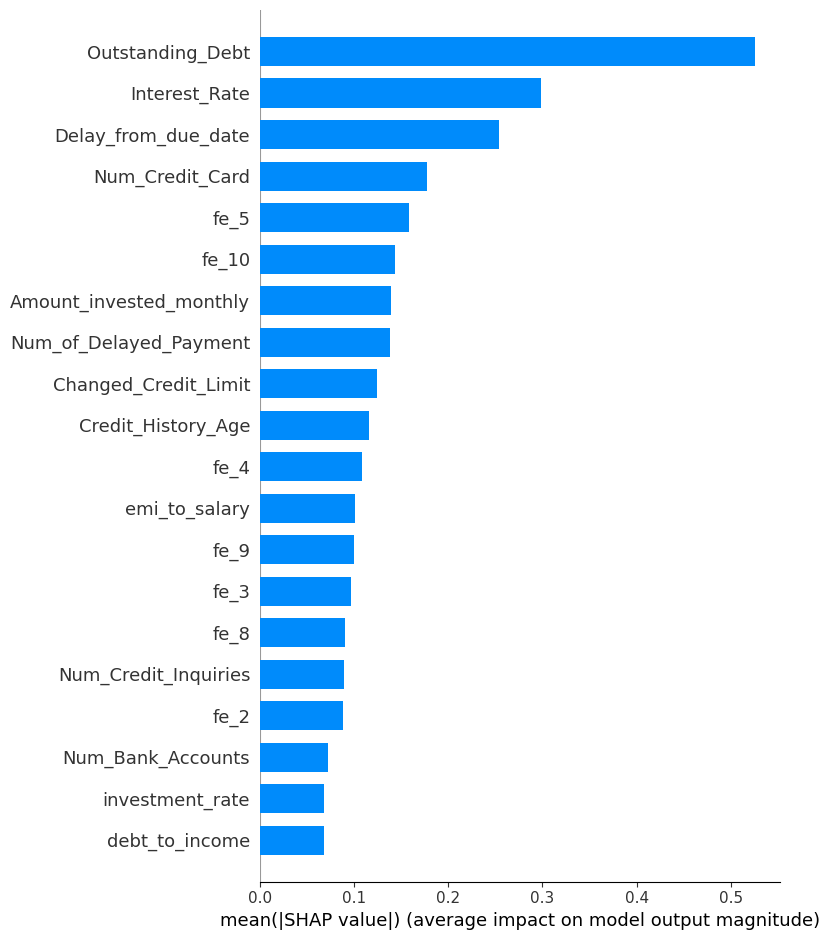

In [24]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

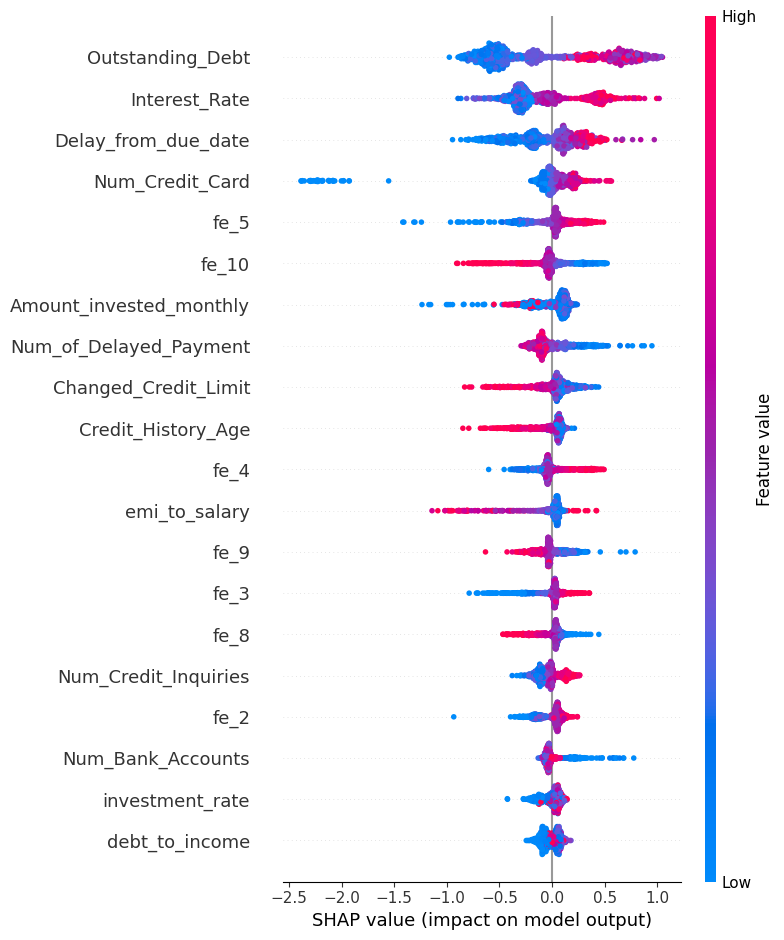

In [25]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [26]:
import pandas as pd
import numpy as np

importance_df = pd.DataFrame({
    "feature": X_sample.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})

importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
)

importance_df.head(10)

,feature,importance
11,Outstanding_Debt,0.526051
5,Interest_Rate,0.298407
7,Delay_from_due_date,0.253647
4,Num_Credit_Card,0.177329
27,fe_5,0.158235
32,fe_10,0.143094
15,Amount_invested_monthly,0.139546
8,Num_of_Delayed_Payment,0.137872
9,Changed_Credit_Limit,0.123977
13,Credit_History_Age,0.115817
